In [1]:
%pip install pandas sqlalchemy ipython-sql jupysql matplotlib
%pip install "prettytable>=3.12.0"

/home/jeriosll/.local/share/uv/tools/jupyterlab/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/jeriosll/.local/share/uv/tools/jupyterlab/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print(sys.version)
print(sys.executable)

3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
/home/jeriosll/.local/share/uv/tools/jupyterlab/bin/python


# Advanced Demo: Five-Year Inventory Optimization and Pricing Strategy

This notebook demonstrates the Advanced goal of the Sari-Sari Store Simulator.

The Advanced goal is to:

- Generate five years of synthetic transaction data
- Add grocery-wide sales events that cause visible demand peaks
- Create monthly inventory snapshots and restock recommendations
- Generate monthly customer feedback
- Run an inventory optimization engine
- Run a pricing strategy engine
- Build a five-year dashboard with event peak detection

## 1. Set up project paths

Because this notebook is inside the `notebooks/` folder, we need to point Python back to the project root so it can import modules from `src/`.

In [3]:
from pathlib import Path
import sys

# The notebook is inside LT6_Final_Project/notebooks/
# Therefore, the project root is one folder above the current notebook folder.
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path so src.* imports work.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/jeriosll/projects/dsc-512/project


In [4]:
# Define important project paths

INVENTORY_PATH   = PROJECT_ROOT / "data/raw/inventory.csv"
OUTPUT_FOLDER    = PROJECT_ROOT / "data/processed/advanced"
DATABASE_PATH    = PROJECT_ROOT / "src/database/sari_sari_store.db"

print("Inventory path :", INVENTORY_PATH)
print("Output folder  :", OUTPUT_FOLDER)
print("Database path  :", DATABASE_PATH)

Inventory path : /home/jeriosll/projects/dsc-512/project/data/raw/inventory.csv
Output folder  : /home/jeriosll/projects/dsc-512/project/data/processed/advanced
Database path  : /home/jeriosll/projects/dsc-512/project/src/database/sari_sari_store.db


In [5]:
# Check that required input file exists

print("inventory.csv exists:", INVENTORY_PATH.exists())

if not INVENTORY_PATH.exists():
    raise FileNotFoundError(f"Missing file: {INVENTORY_PATH}")

inventory.csv exists: True


## 2. Preview the inventory

The Advanced level uses the same `data/raw/inventory.csv` as the master product list.
It is never modified — all outputs go to `data/processed/advanced/`.

In [6]:
import pandas as pd

inventory_raw = pd.read_csv(INVENTORY_PATH)
print(f"Products: {len(inventory_raw)}")
print(f"Categories: {sorted(inventory_raw['category'].unique())}")
display(inventory_raw)

Products: 15
Categories: ['Beverage', 'Food', 'Household', 'Personal Care', 'Snack']


,product_id,product_name,category,starting_stock,unit_cost,unit_price
0,P001,Coke 1L,Beverage,24,60,75
1,P002,Royal 1L,Beverage,18,58,72
2,P003,Bottled Water 500ml,Beverage,30,10,15
3,P004,Piattos Snack,Snack,36,14,18
4,P005,Nova Snack,Snack,32,13,18
5,P006,Lucky Me Beef Noodles,Food,40,10,14
6,P007,Pancit Canton Chilimansi,Food,40,12,16
7,P008,Canned Sardines,Food,25,22,28
8,P009,Corned Beef Small,Food,20,32,42
9,P010,Egg,Food,60,7,10


In [7]:
# Quick margin check — used by the pricing strategy engine
inventory_raw['unit_cost']  = pd.to_numeric(inventory_raw['unit_cost'],  errors='coerce')
inventory_raw['unit_price'] = pd.to_numeric(inventory_raw['unit_price'], errors='coerce')

inventory_raw['gross_margin'] = (
    (inventory_raw['unit_price'] - inventory_raw['unit_cost']) / inventory_raw['unit_price']
).round(3)

display(inventory_raw[['product_id','product_name','category','unit_cost','unit_price','gross_margin']]
        .sort_values('gross_margin', ascending=False))

,product_id,product_name,category,unit_cost,unit_price,gross_margin
12,P013,Shampoo Sachet,Personal Care,4,7,0.429
14,P015,Dishwashing Liquid Sachet,Household,6,10,0.400
11,P012,Coffee Sachet,Beverage,5,8,0.375
13,P014,Laundry Detergent Sachet,Household,5,8,0.375
2,P003,Bottled Water 500ml,Beverage,10,15,0.333
9,P010,Egg,Food,7,10,0.300
5,P006,Lucky Me Beef Noodles,Food,10,14,0.286
4,P005,Nova Snack,Snack,13,18,0.278
6,P007,Pancit Canton Chilimansi,Food,12,16,0.250
8,P009,Corned Beef Small,Food,32,42,0.238


## 3. Run the full Advanced pipeline

This runs all seven steps in order:

1. Generate five years of sales events
2. Generate 60 months of transactions (event-boosted)
3. Generate monthly outputs (transaction details, product summary, ledger summary, inventory before sales)
4. Generate customer feedback
5. Save monthly sales_events.csv per folder
6. Run the inventory optimizer
7. Run the pricing strategy engine and dashboard

Outputs are saved to `data/processed/advanced/` and `src/database/sari_sari_store.db`.

In [8]:
from src.advanced.advanced_runner import run_advanced_pipeline

results = run_advanced_pipeline(
    inventory_csv_path=INVENTORY_PATH,
    output_base_folder=OUTPUT_FOLDER,
    sqlite_db_path=DATABASE_PATH,
    random_seed=42,
    save_csv=True,
    save_sqlite=True,
    verbose=True,
)


ADVANCED GOAL: FULL FIVE-YEAR PIPELINE
Inventory source  : /home/jeriosll/projects/dsc-512/project/data/raw/inventory.csv
Output folder     : /home/jeriosll/projects/dsc-512/project/data/processed/advanced
SQLite database   : /home/jeriosll/projects/dsc-512/project/src/database/sari_sari_store.db
Random seed       : 42

[Step 1 / 7] Generating sales events...

ADVANCED GOAL: SALES EVENT GENERATOR
Total events generated : 110
Average discount rate  : 13.5%
Average demand boost   : 1.40x

Events by category:
  Beverage             : 35 events
  Food                 : 30 events
  Snack                : 20 events
  Household            : 15 events
  Personal Care        : 10 events

Aggregated CSV saved  : /home/jeriosll/projects/dsc-512/project/data/processed/advanced/sales_events.csv
SQLite table saved    : advanced_sales_events → /home/jeriosll/projects/dsc-512/project/src/database/sari_sari_store.db

[Step 2 / 7] Generating five-year transactions...

ADVANCED GOAL: FIVE-YEAR TRANSACTI

In [9]:
# Extract all DataFrames from the results dictionary

sales_events            = results["sales_events"]
all_transactions        = results["all_transactions"]
all_transaction_details = results["all_transaction_details"]
all_product_summaries   = results["all_product_summaries"]
all_ledger_summaries    = results["all_ledger_summaries"]
all_feedback            = results["all_feedback"]
all_restock             = results["all_restock"]
pricing_recommendations = results["pricing_recommendations"]
dashboard               = results["dashboard"]

print("Sales events            :", len(sales_events))
print("Transactions (5yr)      :", len(all_transactions))
print("Transaction details     :", len(all_transaction_details))
print("Product summaries       :", len(all_product_summaries))
print("Ledger summaries        :", len(all_ledger_summaries))
print("Customer feedback       :", len(all_feedback))
print("Restock recommendations :", len(all_restock))
print("Pricing recommendations :", len(pricing_recommendations))
print("Dashboard rows          :", len(dashboard))

Sales events            : 110
Transactions (5yr)      : 23761
Transaction details     : 23761
Product summaries       : 900
Ledger summaries        : 60
Customer feedback       : 2677
Restock recommendations : 900
Pricing recommendations : 15
Dashboard rows          : 343


## 4. Check monthly folder output

Each `year_YYYY/month_MM/` folder should contain all eight files.

In [10]:
# Spot-check one monthly folder — June 2022
sample_folder = OUTPUT_FOLDER / "year_2022" / "month_06"

expected_files = [
    "transactions.csv",
    "transaction_details.csv",
    "product_summary.csv",
    "ledger_summary.csv",
    "restock_recommendations.csv",
    "customer_feedback.csv",
    "sales_events.csv",
    "inventory_before_monthly_sales.csv",
]

print(f"Checking folder: {sample_folder}")
print()
for fname in expected_files:
    path = sample_folder / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

Checking folder: /home/jeriosll/projects/dsc-512/project/data/processed/advanced/year_2022/month_06

  [OK] transactions.csv
  [OK] transaction_details.csv
  [OK] product_summary.csv
  [OK] ledger_summary.csv
  [OK] restock_recommendations.csv
  [OK] customer_feedback.csv
  [OK] sales_events.csv
  [OK] inventory_before_monthly_sales.csv


In [11]:
# Preview each file from the sample folder

for fname in expected_files:
    path = sample_folder / fname
    if path.exists():
        df = pd.read_csv(path)
        print(f"\n--- {fname} ({len(df)} rows) ---")
        display(df.head(3))


--- transactions.csv (387 rows) ---


,transaction_id,transaction_date,product_id,quantity_sold
0,ADV-202206-00001,2022-06-01,P001,6
1,ADV-202206-00002,2022-06-01,P002,4
2,ADV-202206-00003,2022-06-01,P003,16



--- transaction_details.csv (387 rows) ---


,transaction_id,transaction_date,product_id,product_name,category,quantity_sold,unit_cost,unit_price,revenue,expense,gross_profit,starting_stock,total_quantity_sold,remaining_stock
0,ADV-202206-00001,2022-06-01,P001,Coke 1L,Beverage,6,60,75,450,360,90,24,190,0
1,ADV-202206-00002,2022-06-01,P002,Royal 1L,Beverage,4,58,72,288,232,56,18,119,0
2,ADV-202206-00003,2022-06-01,P003,Bottled Water 500ml,Beverage,16,10,15,240,160,80,30,488,0



--- product_summary.csv (15 rows) ---


...

,feedback_id,feedback_date,product_id,product_name,category,rating,comment,sentiment
0,FB-202206-00001,2022-06-16,P001,Coke 1L,Beverage,4.6,"Malamig at masustansya, paborito ng pamilya.",positive
1,FB-202206-00002,2022-06-27,P001,Coke 1L,Beverage,4.8,"Masarap, okay ang presyo.",positive
2,FB-202206-00003,2022-06-21,P001,Coke 1L,Beverage,4.7,Perfect para sa mainit na panahon.,positive



--- sales_events.csv (2 rows) ---


,event_id,event_name,start_date,end_date,discount_rate,affected_category,demand_multiplier
0,EVT-2022-009,Back-to-School Personal Care Sale,2022-06-01,2022-06-07,0.15,Personal Care,1.45
1,EVT-2022-010,Midsummer Beverage Blowout,2022-06-13,2022-06-19,0.20,Beverage,1.60



--- inventory_before_monthly_sales.csv (15 rows) ---


,product_id,product_name,category,starting_stock,unit_cost,unit_price,year,month
0,P001,Coke 1L,Beverage,24,60,75,2022,6
1,P002,Royal 1L,Beverage,18,58,72,2022,6
2,P003,Bottled Water 500ml,Beverage,30,10,15,2022,6


## 5. Inspect sales events

Sales events cause visible demand spikes during their active dates.
Each event affects one product category for a set number of days.

In [12]:
display(sales_events.head(10))
print(f"\nTotal events : {len(sales_events)}")
print(f"Years covered: {sorted(pd.to_datetime(sales_events['start_date']).dt.year.unique())}")
print(f"\nEvents by category:")
print(sales_events.groupby('affected_category').size().sort_values(ascending=False))

,event_id,event_name,start_date,end_date,discount_rate,affected_category,demand_multiplier
0,EVT-2022-001,New Year Clearance Sale,2022-01-08,2022-01-14,0.10,Food,1.30
1,EVT-2022-002,January Beverage Promo,2022-01-21,2022-01-25,0.08,Beverage,1.24
2,EVT-2022-003,Valentine's Day Snack Promo,2022-02-11,2022-02-15,0.12,Snack,1.36
3,EVT-2022-004,Holy Week Canned Food Sale,2022-03-20,2022-03-25,0.15,Food,1.45
4,EVT-2022-005,Summer Kickoff Beverage Sale,2022-04-01,2022-04-05,0.18,Beverage,1.54
5,EVT-2022-006,Summer Snack Festival,2022-04-17,2022-04-23,0.15,Snack,1.45
6,EVT-2022-007,Fiesta Season Food Sale,2022-05-01,2022-05-10,0.12,Food,1.36
7,EVT-2022-008,Household Essentials Promo,2022-05-16,2022-05-20,0.10,Household,1.30
8,EVT-2022-009,Back-to-School Personal Care Sale,2022-06-01,2022-06-07,0.15,Personal Care,1.45
9,EVT-2022-010,Midsummer Beverage Blowout,2022-06-13,2022-06-19,0.20,Beverage,1.60



Total events : 110
Years covered: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Events by category:
affected_category
Beverage         35
Food             30
Snack            20
Household        15
Personal Care    10
dtype: int64


In [13]:
# Which events were active in June 2022?
events_june = sales_events[
    (pd.to_datetime(sales_events['start_date']) <= pd.Timestamp('2022-06-30')) &
    (pd.to_datetime(sales_events['end_date'])   >= pd.Timestamp('2022-06-01'))
]
display(events_june[['event_id','event_name','start_date','end_date','discount_rate','affected_category','demand_multiplier']])

,event_id,event_name,start_date,end_date,discount_rate,affected_category,demand_multiplier
8,EVT-2022-009,Back-to-School Personal Care Sale,2022-06-01,2022-06-07,0.15,Personal Care,1.45
9,EVT-2022-010,Midsummer Beverage Blowout,2022-06-13,2022-06-19,0.20,Beverage,1.60


## 6. Inspect five-year transactions

Transactions are generated daily for all 15 products across 60 months.
Demand is higher in December, on weekends, and during event periods.

In [14]:
print("Shape:", all_transactions.shape)
print("Columns:", list(all_transactions.columns))
display(all_transactions.head())

Shape: (23761, 4)
Columns: ['transaction_id', 'transaction_date', 'product_id', 'quantity_sold']


,transaction_id,transaction_date,product_id,quantity_sold
0,ADV-202201-00001,2022-01-01,P001,4
1,ADV-202201-00002,2022-01-01,P002,4
2,ADV-202201-00003,2022-01-01,P003,13
3,ADV-202201-00004,2022-01-01,P004,16
4,ADV-202201-00005,2022-01-01,P005,4


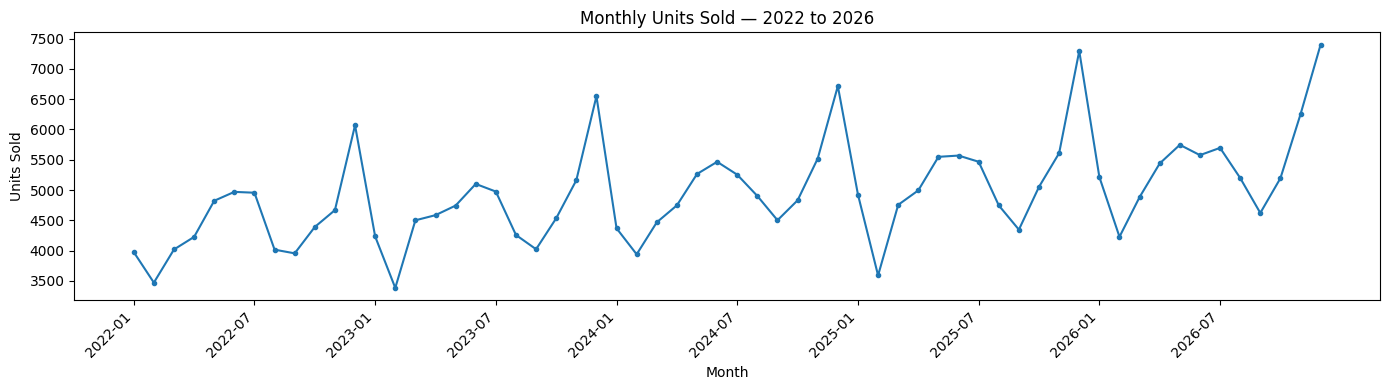

In [15]:
import matplotlib.pyplot as plt

all_transactions['transaction_date'] = pd.to_datetime(all_transactions['transaction_date'])
all_transactions['year']  = all_transactions['transaction_date'].dt.year
all_transactions['month'] = all_transactions['transaction_date'].dt.month

monthly_volume = (
    all_transactions
    .groupby(['year','month'])['quantity_sold']
    .sum()
    .reset_index()
)
monthly_volume['period'] = monthly_volume['year'].astype(str) + '-' + monthly_volume['month'].apply(lambda m: f'{m:02d}')

plt.figure(figsize=(14, 4))
plt.plot(range(len(monthly_volume)), monthly_volume['quantity_sold'], marker='o', markersize=3)
plt.xticks(
    range(0, len(monthly_volume), 6),
    monthly_volume['period'].iloc[::6],
    rotation=45, ha='right'
)
plt.title('Monthly Units Sold — 2022 to 2026')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

In [16]:
# Verify seasonality: December should outsell February every year
comparison = monthly_volume[monthly_volume['month'].isin([2, 12])].pivot(index='year', columns='month', values='quantity_sold')
comparison.columns = ['February', 'December']
comparison['Dec vs Feb'] = (comparison['December'] / comparison['February']).round(2)
print("Seasonality check (December vs February):")
print(comparison)

Seasonality check (December vs February):
      February  December  Dec vs Feb
year                                
2022      3473      6069        1.75
2023      3386      6548        1.93
2024      3940      6715        1.70
2025      3592      7294        2.03
2026      4229      7401        1.75


## 7. Inspect transaction details and ledger summaries

In [17]:
print("Transaction details shape:", all_transaction_details.shape)
print("Columns:", list(all_transaction_details.columns))
display(all_transaction_details.head())

Transaction details shape: (23761, 14)
Columns: ['transaction_id', 'transaction_date', 'product_id', 'product_name', 'category', 'quantity_sold', 'unit_cost', 'unit_price', 'revenue', 'expense', 'gross_profit', 'starting_stock', 'total_quantity_sold', 'remaining_stock']


,transaction_id,transaction_date,product_id,product_name,category,quantity_sold,unit_cost,unit_price,revenue,expense,gross_profit,starting_stock,total_quantity_sold,remaining_stock
0,ADV-202201-00001,2022-01-01,P001,Coke 1L,Beverage,4,60,75,300,240,60,24,162,0
1,ADV-202201-00002,2022-01-01,P002,Royal 1L,Beverage,4,58,72,288,232,56,18,92,0
2,ADV-202201-00003,2022-01-01,P003,Bottled Water 500ml,Beverage,13,10,15,195,130,65,30,390,0
3,ADV-202201-00004,2022-01-01,P004,Piattos Snack,Snack,16,14,18,288,224,64,36,252,0
4,ADV-202201-00005,2022-01-01,P005,Nova Snack,Snack,4,13,18,72,52,20,32,141,0


In [18]:
print("Ledger summaries shape:", all_ledger_summaries.shape)
display(all_ledger_summaries.head(12))

Ledger summaries shape: (60, 13)


,month,year,month_num,month_start,month_end,days_in_month,transaction_count,unique_products_sold,total_quantity_sold,total_revenue,total_expense,gross_profit,gross_margin_rate
0,2022-01,2022,1,2022-01-01,2022-01-31,31,409,15,3977,70311.0,51895.0,18416.0,0.2619
1,2022-02,2022,2,2022-02-01,2022-02-28,28,363,15,3473,58921.0,43269.0,15652.0,0.2656
2,2022-03,2022,3,2022-03-01,2022-03-31,31,402,15,4020,67984.0,49932.0,18052.0,0.2655
3,2022-04,2022,4,2022-04-01,2022-04-30,30,379,15,4227,74028.0,54562.0,19466.0,0.2630
4,2022-05,2022,5,2022-05-01,2022-05-31,31,410,15,4823,81760.0,60107.0,21653.0,0.2648
5,2022-06,2022,6,2022-06-01,2022-06-30,30,387,15,4970,82857.0,60590.0,22267.0,0.2687
6,2022-07,2022,7,2022-07-01,2022-07-31,31,404,15,4956,84324.0,61950.0,22374.0,0.2653
7,2022-08,2022,8,2022-08-01,2022-08-31,31,399,15,4017,69470.0,51052.0,18418.0,0.2651
8,2022-09,2022,9,2022-09-01,2022-09-30,30,398,15,3956,67799.0,49823.0,17976.0,0.2651
9,2022-10,2022,10,2022-10-01,2022-10-31,31,411,15,4391,76158.0,56088.0,20070.0,0.2635


Annual financial summary:


,year,annual_revenue,annual_expense,annual_profit,margin
0,2022,925100.0,680527.0,244573.0,0.264
1,2023,968821.0,712934.0,255887.0,0.264
2,2024,1029064.0,756526.0,272538.0,0.265
3,2025,1068315.0,785882.0,282433.0,0.264
4,2026,1122968.0,825520.0,297448.0,0.265


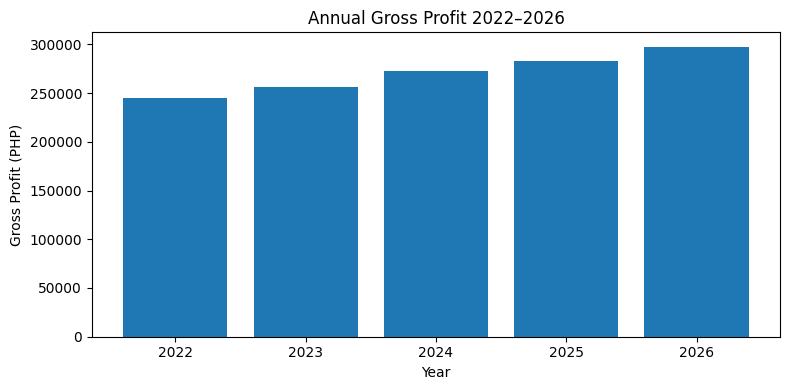

In [19]:
annual = (
    all_ledger_summaries
    .groupby('year', as_index=False)
    .agg(
        annual_revenue=('total_revenue','sum'),
        annual_expense=('total_expense','sum'),
        annual_profit =('gross_profit', 'sum'),
    )
)
annual['margin'] = (annual['annual_profit'] / annual['annual_revenue']).round(3)
print("Annual financial summary:")
display(annual)

plt.figure(figsize=(8,4))
plt.bar(annual['year'].astype(str), annual['annual_profit'])
plt.title('Annual Gross Profit 2022–2026')
plt.xlabel('Year')
plt.ylabel('Gross Profit (PHP)')
plt.tight_layout()
plt.show()

## 8. Inspect customer feedback

In [20]:
print("Shape:", all_feedback.shape)
display(all_feedback.head(10))

Shape: (2677, 8)


,feedback_id,feedback_date,product_id,product_name,category,rating,comment,sentiment
0,FB-202201-00001,2022-01-20,P001,Coke 1L,Beverage,3.4,"Okay lang, walang espesyal.",neutral
1,FB-202201-00002,2022-01-01,P001,Coke 1L,Beverage,4.2,"Laging fresh, hindi mahal.",positive
2,FB-202201-00003,2022-01-09,P001,Coke 1L,Beverage,1.9,Medyo mabilis maubusan dito.,negative
3,FB-202201-00004,2022-01-02,P002,Royal 1L,Beverage,4.5,"Malamig at masustansya, paborito ng pamilya.",positive
4,FB-202201-00005,2022-01-23,P002,Royal 1L,Beverage,4.4,"Laging fresh, hindi mahal.",positive
5,FB-202201-00006,2022-01-09,P003,Bottled Water 500ml,Beverage,4.1,"Laging fresh, hindi mahal.",positive
6,FB-202201-00007,2022-01-23,P003,Bottled Water 500ml,Beverage,1.1,Medyo mahal na ngayon.,negative
7,FB-202201-00008,2022-01-31,P003,Bottled Water 500ml,Beverage,4.6,"Masarap at fresh, sulit ang presyo.",positive
8,FB-202201-00009,2022-01-05,P003,Bottled Water 500ml,Beverage,3.0,"Hindi masama, normal lang.",neutral
9,FB-202201-00010,2022-01-03,P004,Piattos Snack,Snack,1.3,Medyo mahal na para sa laki.,negative


Sentiment distribution:


,sentiment,count,pct
0,negative,610,22.8
1,neutral,471,17.6
2,positive,1596,59.6


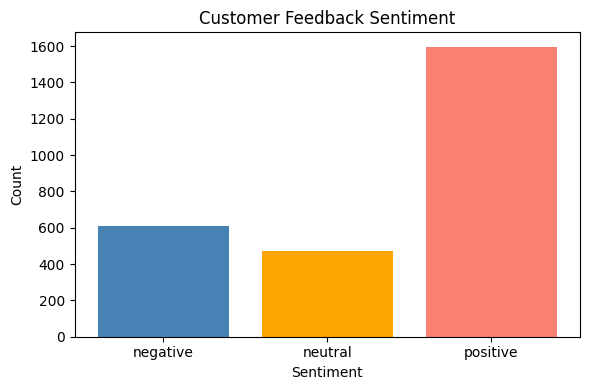

In [21]:
sentiment_counts = all_feedback.groupby('sentiment').size().reset_index(name='count')
sentiment_counts['pct'] = (sentiment_counts['count'] / len(all_feedback) * 100).round(1)
print("Sentiment distribution:")
display(sentiment_counts)

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts['sentiment'], sentiment_counts['count'], color=['steelblue','orange','salmon'])
plt.title('Customer Feedback Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [22]:
avg_rating = (
    all_feedback
    .groupby('product_name')['rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
avg_rating['rating'] = avg_rating['rating'].round(2)
print("Average rating by product:")
display(avg_rating)

Average rating by product:


,product_name,rating
0,Canned Sardines,3.96
1,Dishwashing Liquid Sachet,3.95
2,Lucky Me Beef Noodles,3.91
3,Shampoo Sachet,3.87
4,Coke 1L,3.87
5,Rice 1kg,3.80
6,Piattos Snack,3.78
7,Coffee Sachet,3.76
8,Pancit Canton Chilimansi,3.76
9,Corned Beef Small,3.75


## 9. Inspect inventory optimizer results

The optimizer classifies each product-month as CRITICAL, HIGH, MEDIUM, or LOW risk
and recommends a restock quantity.

In [23]:
print("Shape:", all_restock.shape)
print("Columns:", list(all_restock.columns))
display(all_restock.head(10))

Shape: (900, 13)
Columns: ['product_id', 'product_name', 'category', 'unit_cost', 'unit_price', 'average_monthly_quantity_sold', 'current_stock', 'average_daily_sales', 'stockout_risk', 'recommended_restock_quantity', 'recommendation_reason', 'year', 'month']


,product_id,product_name,category,unit_cost,unit_price,average_monthly_quantity_sold,current_stock,average_daily_sales,stockout_risk,recommended_restock_quantity,recommendation_reason,year,month
0,P010,Egg,Food,7,10,698.0,0,22.52,CRITICAL,1047,Stock at 0 units vs avg monthly demand of 698 ...,2022,1
1,P012,Coffee Sachet,Beverage,5,8,640.0,0,20.65,CRITICAL,960,Stock at 0 units vs avg monthly demand of 640 ...,2022,1
2,P003,Bottled Water 500ml,Beverage,10,15,390.0,0,12.58,CRITICAL,585,Stock at 0 units vs avg monthly demand of 390 ...,2022,1
3,P014,Laundry Detergent Sachet,Household,5,8,326.0,0,10.52,CRITICAL,489,Stock at 0 units vs avg monthly demand of 326 ...,2022,1
4,P006,Lucky Me Beef Noodles,Food,10,14,292.0,0,9.42,CRITICAL,438,Stock at 0 units vs avg monthly demand of 292 ...,2022,1
5,P007,Pancit Canton Chilimansi,Food,12,16,286.0,0,9.23,CRITICAL,429,Stock at 0 units vs avg monthly demand of 286 ...,2022,1
6,P013,Shampoo Sachet,Personal Care,4,7,261.0,0,8.42,CRITICAL,392,Stock at 0 units vs avg monthly demand of 261 ...,2022,1
7,P004,Piattos Snack,Snack,14,18,252.0,0,8.13,CRITICAL,378,Stock at 0 units vs avg monthly demand of 252 ...,2022,1
8,P001,Coke 1L,Beverage,60,75,162.0,0,5.23,CRITICAL,243,Stock at 0 units vs avg monthly demand of 162 ...,2022,1
9,P005,Nova Snack,Snack,13,18,141.0,0,4.55,CRITICAL,212,Stock at 0 units vs avg monthly demand of 141 ...,2022,1


In [24]:
risk_counts = all_restock.groupby('stockout_risk').size().reset_index(name='count')
risk_counts['pct'] = (risk_counts['count'] / len(all_restock) * 100).round(1)
print("Stockout risk distribution across all 60 months:")
display(risk_counts)

Stockout risk distribution across all 60 months:


,stockout_risk,count,pct
0,CRITICAL,900,100.0


In [25]:
critical = all_restock[all_restock['stockout_risk'] == 'CRITICAL'][['product_name','category','year','month','current_stock','average_monthly_quantity_sold','recommended_restock_quantity']]
print(f"CRITICAL stockout entries: {len(critical)}")
display(critical.head(10))

CRITICAL stockout entries: 900


,product_name,category,year,month,current_stock,average_monthly_quantity_sold,recommended_restock_quantity
0,Egg,Food,2022,1,0,698.0,1047
1,Coffee Sachet,Beverage,2022,1,0,640.0,960
2,Bottled Water 500ml,Beverage,2022,1,0,390.0,585
3,Laundry Detergent Sachet,Household,2022,1,0,326.0,489
4,Lucky Me Beef Noodles,Food,2022,1,0,292.0,438
5,Pancit Canton Chilimansi,Food,2022,1,0,286.0,429
6,Shampoo Sachet,Personal Care,2022,1,0,261.0,392
7,Piattos Snack,Snack,2022,1,0,252.0,378
8,Coke 1L,Beverage,2022,1,0,162.0,243
9,Nova Snack,Snack,2022,1,0,141.0,212


## 10. Inspect pricing strategy recommendations

The pricing engine analyses five years of demand trends and gross margins
to recommend price adjustments per product.

In [26]:
print("Shape:", pricing_recommendations.shape)
display(pricing_recommendations)

Shape: (15, 10)


,product_id,product_name,category,current_unit_cost,current_unit_price,average_monthly_quantity_sold,gross_margin,demand_trend,recommended_price,pricing_reason
0,P001,Coke 1L,Beverage,60,75,193.83,0.2000,increasing,78.75,Demand increasing and gross margin is low (20....
1,P002,Royal 1L,Beverage,58,72,116.77,0.1944,increasing,75.60,Demand increasing and gross margin is low (19....
2,P003,Bottled Water 500ml,Beverage,10,15,472.28,0.3333,increasing,15.45,Demand is increasing. Slight price increase of...
3,P004,Piattos Snack,Snack,14,18,312.00,0.2222,increasing,18.90,Demand increasing and gross margin is low (22....
4,P005,Nova Snack,Snack,13,18,169.28,0.2778,stable,18.00,Demand stable and margin acceptable. Holding c...
5,P006,Lucky Me Beef Noodles,Food,10,14,329.02,0.2857,increasing,14.42,Demand is increasing. Slight price increase of...
6,P007,Pancit Canton Chilimansi,Food,12,16,325.05,0.2500,increasing,16.48,Demand is increasing. Slight price increase of...
7,P008,Canned Sardines,Food,22,28,111.35,0.2143,increasing,29.40,Demand increasing and gross margin is low (21....
8,P009,Corned Beef Small,Food,32,42,112.92,0.2381,increasing,44.10,Demand increasing and gross margin is low (23....
9,P010,Egg,Food,7,10,887.13,0.3000,stable,10.00,Demand stable and margin acceptable. Holding c...


In [27]:
pricing_recommendations['price_change'] = (
    pricing_recommendations['recommended_price'] - pricing_recommendations['current_unit_price']
).round(2)
pricing_recommendations['change_pct'] = (
    pricing_recommendations['price_change'] / pricing_recommendations['current_unit_price'] * 100
).round(1)

increases = (pricing_recommendations['price_change'] > 0).sum()
decreases = (pricing_recommendations['price_change'] < 0).sum()
holds     = (pricing_recommendations['price_change'] == 0).sum()

print(f"Price increases recommended : {increases}")
print(f"Price decreases recommended : {decreases}")
print(f"Prices held (no change)     : {holds}")
print()
display(pricing_recommendations[['product_name','category','current_unit_price','recommended_price','price_change','change_pct','demand_trend','gross_margin','pricing_reason']])

Price increases recommended : 9
Price decreases recommended : 0
Prices held (no change)     : 6



,product_name,category,current_unit_price,recommended_price,price_change,change_pct,demand_trend,gross_margin,pricing_reason
0,Coke 1L,Beverage,75,78.75,3.75,5.0,increasing,0.2000,Demand increasing and gross margin is low (20....
1,Royal 1L,Beverage,72,75.60,3.60,5.0,increasing,0.1944,Demand increasing and gross margin is low (19....
2,Bottled Water 500ml,Beverage,15,15.45,0.45,3.0,increasing,0.3333,Demand is increasing. Slight price increase of...
3,Piattos Snack,Snack,18,18.90,0.90,5.0,increasing,0.2222,Demand increasing and gross margin is low (22....
4,Nova Snack,Snack,18,18.00,0.00,0.0,stable,0.2778,Demand stable and margin acceptable. Holding c...
5,Lucky Me Beef Noodles,Food,14,14.42,0.42,3.0,increasing,0.2857,Demand is increasing. Slight price increase of...
6,Pancit Canton Chilimansi,Food,16,16.48,0.48,3.0,increasing,0.2500,Demand is increasing. Slight price increase of...
7,Canned Sardines,Food,28,29.40,1.40,5.0,increasing,0.2143,Demand increasing and gross margin is low (21....
8,Corned Beef Small,Food,42,44.10,2.10,5.0,increasing,0.2381,Demand increasing and gross margin is low (23....
9,Egg,Food,10,10.00,0.00,0.0,stable,0.3000,Demand stable and margin acceptable. Holding c...


## 11. Inspect the advanced dashboard

The dashboard is a normalized table with `event_flag=True` on months where
a grocery-wide sales event was active — making promo peaks visible.

In [28]:
print("Dashboard shape:", dashboard.shape)
print("Metric groups:")
print(dashboard['metric_group'].unique())
display(dashboard.head(10))

Dashboard shape: (343, 6)
Metric groups:
<StringArray>
[               'kpi_summary',      'monthly_revenue_trend',
         'monthly_unit_trend', 'monthly_gross_profit_trend',
          'event_peak_months',       'top_selling_products',
      'lowest_stock_products',          'sales_by_category',
             'annual_summary']
Length: 9, dtype: str


,metric_group,metric_name,dimension,value,rank,event_flag
0,kpi_summary,total_revenue_5yr,five_year,5.114268e+06,NaN,False
1,kpi_summary,total_expense_5yr,five_year,3.761389e+06,NaN,False
2,kpi_summary,total_gross_profit_5yr,five_year,1.352879e+06,NaN,False
3,kpi_summary,total_units_sold_5yr,five_year,2.969380e+05,NaN,False
4,kpi_summary,total_transactions_5yr,five_year,2.376100e+04,NaN,False
5,kpi_summary,avg_monthly_revenue,five_year,8.523780e+04,NaN,False
6,kpi_summary,avg_monthly_gross_profit,five_year,2.254798e+04,NaN,False
7,kpi_summary,overall_gross_margin_rate,five_year,2.645000e-01,NaN,False
8,monthly_revenue_trend,monthly_revenue,2022-01,7.031100e+04,NaN,True
9,monthly_unit_trend,monthly_units_sold,2022-01,3.977000e+03,NaN,True


In [29]:
kpis = dashboard[dashboard['metric_group'] == 'kpi_summary'][['metric_name','value']]
print("Five-year KPI summary:")
display(kpis)

Five-year KPI summary:


,metric_name,value
0,total_revenue_5yr,5.114268e+06
1,total_expense_5yr,3.761389e+06
2,total_gross_profit_5yr,1.352879e+06
3,total_units_sold_5yr,2.969380e+05
4,total_transactions_5yr,2.376100e+04
5,avg_monthly_revenue,8.523780e+04
6,avg_monthly_gross_profit,2.254798e+04
7,overall_gross_margin_rate,2.645000e-01


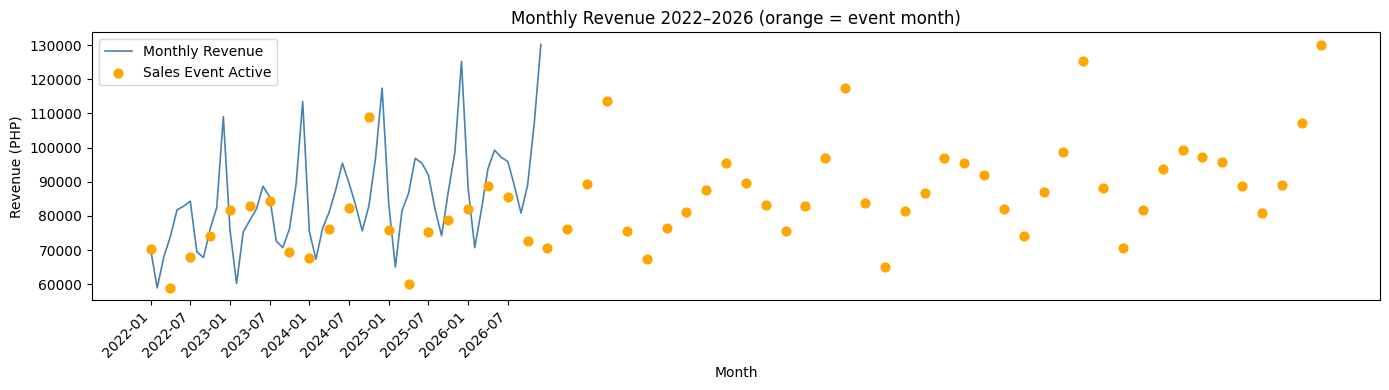

In [30]:
trend = dashboard[
    (dashboard['metric_group'] == 'monthly_revenue_trend') &
    (dashboard['metric_name']  == 'monthly_revenue')
].copy().reset_index(drop=True)

trend['value'] = pd.to_numeric(trend['value'])
event_months   = trend[trend['event_flag'] == True]
normal_months  = trend[trend['event_flag'] == False]

plt.figure(figsize=(14, 4))
plt.plot(trend.index, trend['value'], color='steelblue', linewidth=1.2, label='Monthly Revenue')
plt.scatter(
    event_months.index,
    event_months['value'],
    color='orange', zorder=5, s=40, label='Sales Event Active'
)
plt.xticks(
    range(0, len(trend), 6),
    trend['dimension'].iloc[::6].values,
    rotation=45, ha='right'
)
plt.title('Monthly Revenue 2022–2026 (orange = event month)')
plt.xlabel('Month')
plt.ylabel('Revenue (PHP)')
plt.legend()
plt.tight_layout()
plt.show()

Five-year revenue by category:


,dimension,value,rank
313,Beverage,2237337.0,1.0
315,Food,1927520.0,2.0
317,Snack,519786.0,3.0
319,Household,279678.0,4.0
321,Personal Care,149947.0,5.0


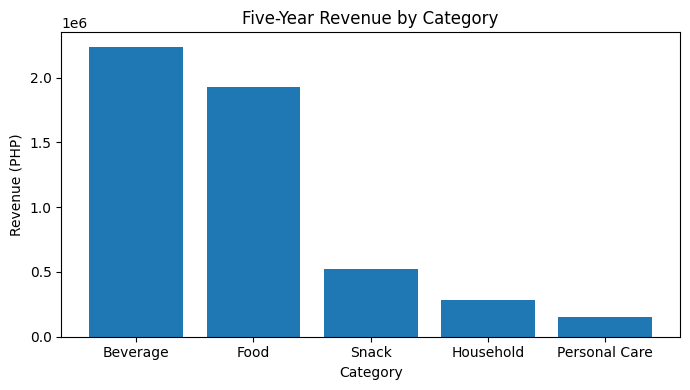

In [31]:
cat_rev = dashboard[
    (dashboard['metric_group'] == 'sales_by_category') &
    (dashboard['metric_name']  == 'category_revenue_5yr')
][['dimension','value','rank']].sort_values('rank')

cat_rev['value'] = pd.to_numeric(cat_rev['value'])
print("Five-year revenue by category:")
display(cat_rev)

plt.figure(figsize=(7,4))
plt.bar(cat_rev['dimension'], cat_rev['value'])
plt.title('Five-Year Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (PHP)')
plt.tight_layout()
plt.show()

In [32]:
annual_dash = dashboard[
    (dashboard['metric_group'] == 'annual_summary') &
    (dashboard['metric_name']  == 'annual_gross_profit')
][['dimension','value']].rename(columns={'dimension':'year','value':'gross_profit'})
annual_dash['gross_profit'] = pd.to_numeric(annual_dash['gross_profit'])
print("Year-by-year gross profit from dashboard:")
display(annual_dash)

Year-by-year gross profit from dashboard:


,year,gross_profit
325,2022,244573.0
329,2023,255887.0
333,2024,272538.0
337,2025,282433.0
341,2026,297448.0


## 12. Connect to SQLite using SQL Magic

Now we inspect all Advanced tables directly with SQL queries.

In [33]:
%load_ext sql

In [34]:
# Connect to the shared database
%sql sqlite:///../src/database/sari_sari_store.db

Connecting to 'sqlite:///../src/database/sari_sari_store.db'

In [35]:
%%sql

SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

name
advanced_customer_feedback
advanced_inventory_recommendations
advanced_monthly_dashboard_data
advanced_monthly_ledger_summary
advanced_monthly_product_summary
advanced_pricing_recommendations
advanced_sales_events
advanced_transaction_details_5yr
advanced_transactions_5yr
daily_ledger_summary


## 13. Inspect SQLite tables

In [36]:
%%sql

SELECT *
FROM advanced_sales_events
LIMIT 10;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

event_id,event_name,start_date,end_date,discount_rate,affected_category,demand_multiplier
EVT-2022-001,New Year Clearance Sale,2022-01-08 00:00:00.000000,2022-01-14 00:00:00.000000,0.1,Food,1.3
EVT-2022-002,January Beverage Promo,2022-01-21 00:00:00.000000,2022-01-25 00:00:00.000000,0.08,Beverage,1.24
EVT-2022-003,Valentine's Day Snack Promo,2022-02-11 00:00:00.000000,2022-02-15 00:00:00.000000,0.12,Snack,1.36
EVT-2022-004,Holy Week Canned Food Sale,2022-03-20 00:00:00.000000,2022-03-25 00:00:00.000000,0.15,Food,1.45
EVT-2022-005,Summer Kickoff Beverage Sale,2022-04-01 00:00:00.000000,2022-04-05 00:00:00.000000,0.18,Beverage,1.54
EVT-2022-006,Summer Snack Festival,2022-04-17 00:00:00.000000,2022-04-23 00:00:00.000000,0.15,Snack,1.45
EVT-2022-007,Fiesta Season Food Sale,2022-05-01 00:00:00.000000,2022-05-10 00:00:00.000000,0.12,Food,1.36
EVT-2022-008,Household Essentials Promo,2022-05-16 00:00:00.000000,2022-05-20 00:00:00.000000,0.1,Household,1.3
EVT-2022-009,Back-to-School Personal Care Sale,2022-06-01 00:00:00.000000,2022-06-07 00:00:00.000000,0.15,Personal Care,1.45
EVT-2022-010,Midsummer Beverage Blowout,2022-06-13 00:00:00.000000,2022-06-19 00:00:00.000000,0.2,Beverage,1.6


In [37]:
%%sql

SELECT *
FROM advanced_transactions_5yr
LIMIT 10;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

transaction_id,transaction_date,product_id,quantity_sold
ADV-202201-00001,2022-01-01 00:00:00.000000,P001,4
ADV-202201-00002,2022-01-01 00:00:00.000000,P002,4
ADV-202201-00003,2022-01-01 00:00:00.000000,P003,13
ADV-202201-00004,2022-01-01 00:00:00.000000,P004,16
ADV-202201-00005,2022-01-01 00:00:00.000000,P005,4
ADV-202201-00006,2022-01-01 00:00:00.000000,P006,13
ADV-202201-00007,2022-01-01 00:00:00.000000,P007,13
ADV-202201-00008,2022-01-01 00:00:00.000000,P008,4
ADV-202201-00009,2022-01-01 00:00:00.000000,P009,3
ADV-202201-00010,2022-01-01 00:00:00.000000,P010,23


In [38]:
%%sql

SELECT *
FROM advanced_transaction_details_5yr
LIMIT 10;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

transaction_id,transaction_date,product_id,product_name,category,quantity_sold,unit_cost,unit_price,revenue,expense,gross_profit,starting_stock,total_quantity_sold,remaining_stock
ADV-202201-00001,2022-01-01 00:00:00.000000,P001,Coke 1L,Beverage,4,60,75,300,240,60,24,162,0
ADV-202201-00002,2022-01-01 00:00:00.000000,P002,Royal 1L,Beverage,4,58,72,288,232,56,18,92,0
ADV-202201-00003,2022-01-01 00:00:00.000000,P003,Bottled Water 500ml,Beverage,13,10,15,195,130,65,30,390,0
ADV-202201-00004,2022-01-01 00:00:00.000000,P004,Piattos Snack,Snack,16,14,18,288,224,64,36,252,0
ADV-202201-00005,2022-01-01 00:00:00.000000,P005,Nova Snack,Snack,4,13,18,72,52,20,32,141,0
ADV-202201-00006,2022-01-01 00:00:00.000000,P006,Lucky Me Beef Noodles,Food,13,10,14,182,130,52,40,292,0
ADV-202201-00007,2022-01-01 00:00:00.000000,P007,Pancit Canton Chilimansi,Food,13,12,16,208,156,52,40,286,0
ADV-202201-00008,2022-01-01 00:00:00.000000,P008,Canned Sardines,Food,4,22,28,112,88,24,25,106,0
ADV-202201-00009,2022-01-01 00:00:00.000000,P009,Corned Beef Small,Food,3,32,42,126,96,30,20,98,0
ADV-202201-00010,2022-01-01 00:00:00.000000,P010,Egg,Food,23,7,10,230,161,69,60,698,0


In [39]:
%%sql

SELECT *
FROM advanced_monthly_product_summary
WHERE year = 2022 AND month = 6
ORDER BY total_quantity_sold DESC;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

product_id,product_name,category,starting_stock,unit_cost,unit_price,total_quantity_sold,total_revenue,total_expense,gross_profit,gross_margin_rate,transaction_count,remaining_stock,average_daily_sales,sell_through_rate,year,month
P012,Coffee Sachet,Beverage,80,5,8,1014,8112,5070,3042,0.375,30,0,33.8,12.675,2022,6
P010,Egg,Food,60,7,10,880,8800,6160,2640,0.3,29,0,29.33,14.6667,2022,6
P003,Bottled Water 500ml,Beverage,30,10,15,488,7320,4880,2440,0.3333,27,0,16.27,16.2667,2022,6
P014,Laundry Detergent Sachet,Household,75,5,8,434,3472,2170,1302,0.375,28,0,14.47,5.7867,2022,6
P013,Shampoo Sachet,Personal Care,70,4,7,377,2639,1508,1131,0.4286,23,0,12.57,5.3857,2022,6
P006,Lucky Me Beef Noodles,Food,40,10,14,299,4186,2990,1196,0.2857,26,0,9.97,7.475,2022,6
P004,Piattos Snack,Snack,36,14,18,290,5220,4060,1160,0.2222,25,0,9.67,8.0556,2022,6
P007,Pancit Canton Chilimansi,Food,40,12,16,285,4560,3420,1140,0.25,24,0,9.5,7.125,2022,6
P001,Coke 1L,Beverage,24,60,75,190,14250,11400,2850,0.2,28,0,6.33,7.9167,2022,6
P005,Nova Snack,Snack,32,13,18,172,3096,2236,860,0.2778,26,0,5.73,5.375,2022,6


In [40]:
%%sql

SELECT *
FROM advanced_monthly_ledger_summary
ORDER BY year, month;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

month,year,month_num,month_start,month_end,days_in_month,transaction_count,unique_products_sold,total_quantity_sold,total_revenue,total_expense,gross_profit,gross_margin_rate
2022-01,2022,1,2022-01-01,2022-01-31,31,409,15,3977,70311.0,51895.0,18416.0,0.2619
2022-02,2022,2,2022-02-01,2022-02-28,28,363,15,3473,58921.0,43269.0,15652.0,0.2656
2022-03,2022,3,2022-03-01,2022-03-31,31,402,15,4020,67984.0,49932.0,18052.0,0.2655
2022-04,2022,4,2022-04-01,2022-04-30,30,379,15,4227,74028.0,54562.0,19466.0,0.263
2022-05,2022,5,2022-05-01,2022-05-31,31,410,15,4823,81760.0,60107.0,21653.0,0.2648
2022-06,2022,6,2022-06-01,2022-06-30,30,387,15,4970,82857.0,60590.0,22267.0,0.2687
2022-07,2022,7,2022-07-01,2022-07-31,31,404,15,4956,84324.0,61950.0,22374.0,0.2653
2022-08,2022,8,2022-08-01,2022-08-31,31,399,15,4017,69470.0,51052.0,18418.0,0.2651
2022-09,2022,9,2022-09-01,2022-09-30,30,398,15,3956,67799.0,49823.0,17976.0,0.2651
2022-10,2022,10,2022-10-01,2022-10-31,31,411,15,4391,76158.0,56088.0,20070.0,0.2635


In [41]:
%%sql

SELECT *
FROM advanced_customer_feedback
LIMIT 10;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

feedback_id,feedback_date,product_id,product_name,category,rating,comment,sentiment
FB-202201-00001,2022-01-20 00:00:00.000000,P001,Coke 1L,Beverage,3.4,"Okay lang, walang espesyal.",neutral
FB-202201-00002,2022-01-01 00:00:00.000000,P001,Coke 1L,Beverage,4.2,"Laging fresh, hindi mahal.",positive
FB-202201-00003,2022-01-09 00:00:00.000000,P001,Coke 1L,Beverage,1.9,Medyo mabilis maubusan dito.,negative
FB-202201-00004,2022-01-02 00:00:00.000000,P002,Royal 1L,Beverage,4.5,"Malamig at masustansya, paborito ng pamilya.",positive
FB-202201-00005,2022-01-23 00:00:00.000000,P002,Royal 1L,Beverage,4.4,"Laging fresh, hindi mahal.",positive
FB-202201-00006,2022-01-09 00:00:00.000000,P003,Bottled Water 500ml,Beverage,4.1,"Laging fresh, hindi mahal.",positive
FB-202201-00007,2022-01-23 00:00:00.000000,P003,Bottled Water 500ml,Beverage,1.1,Medyo mahal na ngayon.,negative
FB-202201-00008,2022-01-31 00:00:00.000000,P003,Bottled Water 500ml,Beverage,4.6,"Masarap at fresh, sulit ang presyo.",positive
FB-202201-00009,2022-01-05 00:00:00.000000,P003,Bottled Water 500ml,Beverage,3.0,"Hindi masama, normal lang.",neutral
FB-202201-00010,2022-01-03 00:00:00.000000,P004,Piattos Snack,Snack,1.3,Medyo mahal na para sa laki.,negative


In [42]:
%%sql

SELECT *
FROM advanced_inventory_recommendations
WHERE stockout_risk IN ('CRITICAL','HIGH')
ORDER BY year, month
LIMIT 20;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

product_id,product_name,category,unit_cost,unit_price,average_monthly_quantity_sold,current_stock,average_daily_sales,stockout_risk,recommended_restock_quantity,recommendation_reason,year,month
P010,Egg,Food,7,10,698.0,0,22.52,CRITICAL,1047,Stock at 0 units vs avg monthly demand of 698 units. Stockout risk: CRITICAL. Recommend ordering 1047 units.,2022,1
P012,Coffee Sachet,Beverage,5,8,640.0,0,20.65,CRITICAL,960,Stock at 0 units vs avg monthly demand of 640 units. Stockout risk: CRITICAL. Recommend ordering 960 units.,2022,1
P003,Bottled Water 500ml,Beverage,10,15,390.0,0,12.58,CRITICAL,585,Stock at 0 units vs avg monthly demand of 390 units. Stockout risk: CRITICAL. Recommend ordering 585 units.,2022,1
P014,Laundry Detergent Sachet,Household,5,8,326.0,0,10.52,CRITICAL,489,Stock at 0 units vs avg monthly demand of 326 units. Stockout risk: CRITICAL. Recommend ordering 489 units.,2022,1
P006,Lucky Me Beef Noodles,Food,10,14,292.0,0,9.42,CRITICAL,438,Stock at 0 units vs avg monthly demand of 292 units. Stockout risk: CRITICAL. Recommend ordering 438 units.,2022,1
P007,Pancit Canton Chilimansi,Food,12,16,286.0,0,9.23,CRITICAL,429,Stock at 0 units vs avg monthly demand of 286 units. Stockout risk: CRITICAL. Recommend ordering 429 units.,2022,1
P013,Shampoo Sachet,Personal Care,4,7,261.0,0,8.42,CRITICAL,392,Stock at 0 units vs avg monthly demand of 261 units. Stockout risk: CRITICAL. Recommend ordering 392 units.,2022,1
P004,Piattos Snack,Snack,14,18,252.0,0,8.13,CRITICAL,378,Stock at 0 units vs avg monthly demand of 252 units. Stockout risk: CRITICAL. Upcoming sales event may increase demand — order early. Recommend ordering 378 units.,2022,1
P001,Coke 1L,Beverage,60,75,162.0,0,5.23,CRITICAL,243,Stock at 0 units vs avg monthly demand of 162 units. Stockout risk: CRITICAL. Recommend ordering 243 units.,2022,1
P005,Nova Snack,Snack,13,18,141.0,0,4.55,CRITICAL,212,Stock at 0 units vs avg monthly demand of 141 units. Stockout risk: CRITICAL. Upcoming sales event may increase demand — order early. Recommend ordering 212 units.,2022,1


In [43]:
%%sql

SELECT *
FROM advanced_pricing_recommendations
ORDER BY product_id;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

product_id,product_name,category,current_unit_cost,current_unit_price,average_monthly_quantity_sold,gross_margin,demand_trend,recommended_price,pricing_reason
P001,Coke 1L,Beverage,60,75,193.83,0.2,increasing,78.75,Demand increasing and gross margin is low (20.0%). Raising price by 5% to improve margin.
P002,Royal 1L,Beverage,58,72,116.77,0.1944,increasing,75.6,Demand increasing and gross margin is low (19.4%). Raising price by 5% to improve margin.
P003,Bottled Water 500ml,Beverage,10,15,472.28,0.3333,increasing,15.45,Demand is increasing. Slight price increase of 3%.
P004,Piattos Snack,Snack,14,18,312.0,0.2222,increasing,18.9,Demand increasing and gross margin is low (22.2%). Raising price by 5% to improve margin.
P005,Nova Snack,Snack,13,18,169.28,0.2778,stable,18.0,Demand stable and margin acceptable. Holding current price.
P006,Lucky Me Beef Noodles,Food,10,14,329.02,0.2857,increasing,14.42,Demand is increasing. Slight price increase of 3%.
P007,Pancit Canton Chilimansi,Food,12,16,325.05,0.25,increasing,16.48,Demand is increasing. Slight price increase of 3%.
P008,Canned Sardines,Food,22,28,111.35,0.2143,increasing,29.4,Demand increasing and gross margin is low (21.4%). Raising price by 5% to improve margin.
P009,Corned Beef Small,Food,32,42,112.92,0.2381,increasing,44.1,Demand increasing and gross margin is low (23.8%). Raising price by 5% to improve margin.
P010,Egg,Food,7,10,887.13,0.3,stable,10.0,Demand stable and margin acceptable. Holding current price.


In [44]:
%%sql

SELECT *
FROM advanced_monthly_dashboard_data
WHERE metric_group = 'kpi_summary';

Running query in 'sqlite:///../src/database/sari_sari_store.db'

metric_group,metric_name,dimension,value,rank,event_flag
kpi_summary,total_revenue_5yr,five_year,5114268.0,None,0
kpi_summary,total_expense_5yr,five_year,3761389.0,None,0
kpi_summary,total_gross_profit_5yr,five_year,1352879.0,None,0
kpi_summary,total_units_sold_5yr,five_year,296938.0,None,0
kpi_summary,total_transactions_5yr,five_year,23761.0,None,0
kpi_summary,avg_monthly_revenue,five_year,85237.8,None,0
kpi_summary,avg_monthly_gross_profit,five_year,22547.98,None,0
kpi_summary,overall_gross_margin_rate,five_year,0.2645,None,0


## 14. SQL query — event peak months

This query pulls the months where a sales event was active and shows
the revenue boost compared to the five-year monthly average.

In [45]:
%%sql

SELECT
    dimension                        AS month,
    ROUND(CAST(value AS FLOAT), 2)   AS monthly_revenue,
    event_flag
FROM advanced_monthly_dashboard_data
WHERE metric_group = 'monthly_revenue_trend'
  AND metric_name  = 'monthly_revenue'
ORDER BY month;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

month,monthly_revenue,event_flag
2022-01,70311.0,1
2022-02,58921.0,1
2022-03,67984.0,1
2022-04,74028.0,1
2022-05,81760.0,1
2022-06,82857.0,1
2022-07,84324.0,1
2022-08,69470.0,1
2022-09,67799.0,1
2022-10,76158.0,1


## 15. SQL ledger verification

Recalculate five-year totals directly from `advanced_transaction_details_5yr`
and compare with the stored ledger summaries.

In [46]:
%%sql

SELECT
    SUM(revenue)      AS total_revenue_calc,
    SUM(expense)      AS total_expense_calc,
    SUM(gross_profit) AS total_profit_calc
FROM advanced_transaction_details_5yr;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

total_revenue_calc,total_expense_calc,total_profit_calc
5114268,3761389,1352879


In [47]:
%%sql

SELECT
    SUM(total_revenue) AS total_revenue_ledger,
    SUM(total_expense) AS total_expense_ledger,
    SUM(gross_profit)  AS total_profit_ledger
FROM advanced_monthly_ledger_summary;

Running query in 'sqlite:///../src/database/sari_sari_store.db'

total_revenue_ledger,total_expense_ledger,total_profit_ledger
5114268.0,3761389.0,1352879.0


## 16. Final Advanced goal validation

In [48]:
checks = {
    "sales_events_generated":        len(sales_events) > 0,
    "transactions_generated":        len(all_transactions) > 0,
    "transaction_details_generated": len(all_transaction_details) > 0,
    "product_summaries_generated":   len(all_product_summaries) > 0,
    "ledger_summaries_generated":    len(all_ledger_summaries) > 0,
    "feedback_generated":            len(all_feedback) > 0,
    "restock_recommendations":       len(all_restock) > 0,
    "pricing_recommendations":       len(pricing_recommendations) > 0,
    "dashboard_generated":           len(dashboard) > 0,
    "60_months_covered":             all_ledger_summaries.shape[0] == 60,
    "event_peaks_flagged":           dashboard[dashboard['event_flag'] == True].shape[0] > 0,
    "monthly_folder_files_exist":    (OUTPUT_FOLDER / 'year_2022' / 'month_06' / 'transaction_details.csv').exists(),
    "inventory_before_exists":       (OUTPUT_FOLDER / 'year_2022' / 'month_06' / 'inventory_before_monthly_sales.csv').exists(),
    "sqlite_db_exists":              DATABASE_PATH.exists(),
}

print("Advanced goal validation checklist:")
print()
all_passed = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_passed = False
    print(f"  [{status}] {check}")

print()
if all_passed:
    print("Advanced goal completed successfully.")
else:
    print("Some checks failed — review the output above.")

Advanced goal validation checklist:

  [PASS] sales_events_generated
  [PASS] transactions_generated
  [PASS] transaction_details_generated
  [PASS] product_summaries_generated
  [PASS] ledger_summaries_generated
  [PASS] feedback_generated
  [PASS] restock_recommendations
  [PASS] pricing_recommendations
  [PASS] dashboard_generated
  [PASS] 60_months_covered
  [PASS] event_peaks_flagged
  [PASS] monthly_folder_files_exist
  [PASS] inventory_before_exists
  [PASS] sqlite_db_exists

Advanced goal completed successfully.


## End of Advanced Demo

This notebook demonstrated the Advanced level of the Sari-Sari Store Simulator.

The main project logic is stored in `.py` files under `src/advanced/`.

This notebook is only used for demonstration, validation, SQL Magic inspection, and visualizations.

In [49]:
# Cleanup: close all open database connections.
# This releases the lock on sari_sari_store.db so the next notebook
# can write to it without needing a kernel restart.
try:
    from sql.connection import ConnectionManager
    ConnectionManager.close_all()
    print("All SQL connections closed.")
except Exception as e:
    print(f"Skipped (SQL magic not loaded): {e}")


All SQL connections closed.
